# Media Bias Analysis Report
### Automated Detection of News Framing and Sentiment Asymmetry

This notebook provides a comprehensive visual analysis of the news headlines fetched from multiple sources. We analyze bias using a multi-stage pipeline involving:
1. **Semantic Clustering**: Grouping headlines by story using Sentence-Transformers.
2. **Framing Analysis**: Identifying subject/object roles via SpaCy dependency parsing.
3. **Weighted Scoring**: Applying linguistic and sentiment weights to detect directional bias.

In [1]:
import sqlite3
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Load Data from SQLite
We fetch the processed headlines, their source labels, and the calculated bias scores.

In [2]:
conn = sqlite3.connect('../data/headlines_db.sqlite')
query = "SELECT source_name, sentiment, bias, features FROM headlines"
df_raw = pd.read_sql_query(query, conn)
conn.close()

# Parse JSON columns
df_raw['bias_label'] = df_raw['bias'].apply(lambda x: json.loads(x).get('bias_label') if x else 'neutral')
df_raw['bias_score'] = df_raw['bias'].apply(lambda x: json.loads(x).get('bias_score') if x else 0.0)
df_raw['sentiment_compound'] = df_raw['sentiment'].apply(lambda x: json.loads(x).get('compound') if x else 0.0)

df_raw.head()

,source_name,sentiment,bias,features,bias_label,bias_score,sentiment_compound
0,BBC,"{""neg"": 0.0, ""neu"": 1.0, ""pos"": 0.0, ""compound...","{""bias_score"": 0.0, ""bias_label"": ""neutral"", ""...","{""neg_word_count"": 0, ""pos_word_count"": 0, ""in...",neutral,0.00,0.0000
1,BBC,"{""neg"": 0.421, ""neu"": 0.579, ""pos"": 0.0, ""comp...","{""bias_score"": 4.62, ""bias_label"": ""biased_neg...","{""neg_word_count"": 1, ""pos_word_count"": 0, ""in...",biased_negative,4.62,-0.6249
2,BBC,"{""neg"": 0.0, ""neu"": 1.0, ""pos"": 0.0, ""compound...","{""bias_score"": 0.0, ""bias_label"": ""neutral"", ""...","{""neg_word_count"": 0, ""pos_word_count"": 0, ""in...",neutral,0.00,0.0000
3,BBC,"{""neg"": 0.143, ""neu"": 0.857, ""pos"": 0.0, ""comp...","{""bias_score"": 0.75, ""bias_label"": ""neutral"", ...","{""neg_word_count"": 0, ""pos_word_count"": 0, ""in...",neutral,0.75,-0.2500
4,BBC,"{""neg"": 0.517, ""neu"": 0.483, ""pos"": 0.0, ""comp...","{""bias_score"": 2.45, ""bias_label"": ""biased_neg...","{""neg_word_count"": 0, ""pos_word_count"": 0, ""in...",biased_negative,2.45,-0.8176


## 2. Bias Distribution per Source
This chart helps identify which sources tend to use more biased language in their headlines. We distinguish between **Biased Negative** (negative framing/tone) and **Biased Positive** (supportive tone).

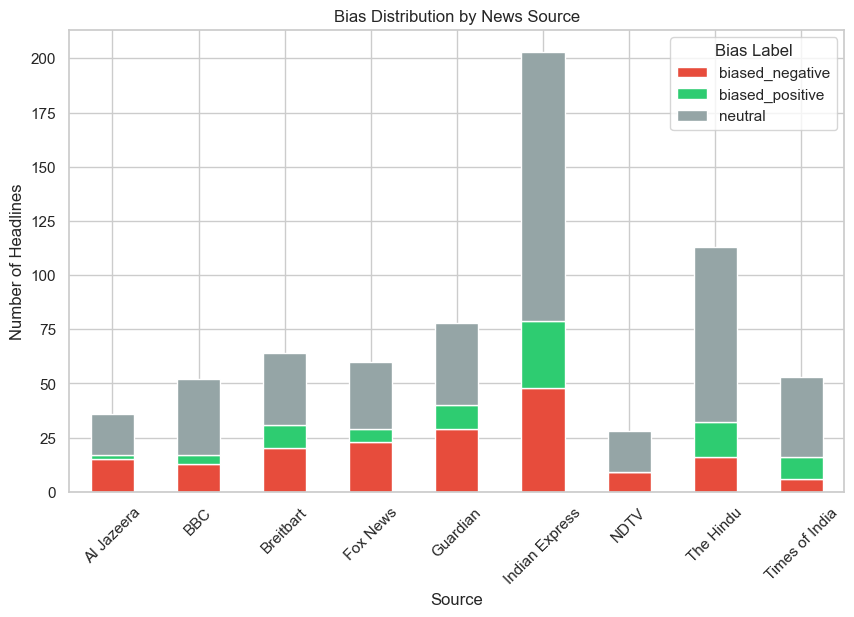

In [3]:
bias_counts = df_raw.groupby(['source_name', 'bias_label']).size().unstack(fill_value=0)
bias_counts.plot(kind='bar', stacked=True, color=['#e74c3c', '#2ecc71', '#95a5a6'])
plt.title("Bias Distribution by News Source")
plt.ylabel("Number of Headlines")
plt.xlabel("Source")
plt.legend(title="Bias Label")
plt.xticks(rotation=45)
plt.show()

### Key Insights:
- If a source shows high red bars, it indicates a tendency to use **negative loaded language** or critical framing.
- Sources with high grey bars maintain a more **neutral/factual** headline style.

## 3. Global Bias Statistics
How much of the total corpus is considered biased vs neutral?

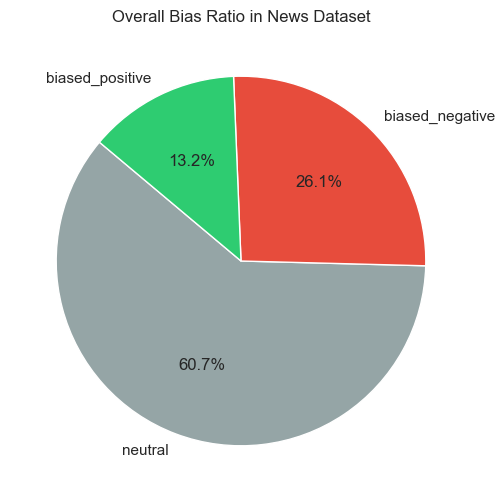

In [4]:
global_counts = df_raw['bias_label'].value_counts()
plt.pie(global_counts, labels=global_counts.index, autopct='%1.1f%%', colors=['#95a5a6', '#e74c3c', '#2ecc71'], startangle=140)
plt.title("Overall Bias Ratio in News Dataset")
plt.show()

## 4. Bias Score Intensity (Histogram)
Most headlines should fall near zero. Significant deviations (outliers) represent extreme framing.

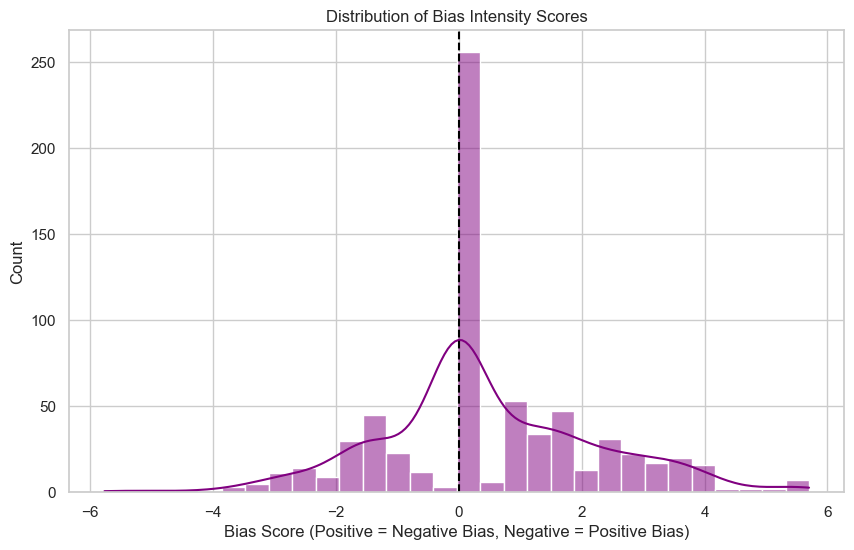

In [5]:
sns.histplot(df_raw['bias_score'], bins=30, kde=True, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title("Distribution of Bias Intensity Scores")
plt.xlabel("Bias Score (Positive = Negative Bias, Negative = Positive Bias)")
plt.show()

## 5. Source Comparison: Average Bias Level
Comparing the average 'intensity' of bias across platforms.

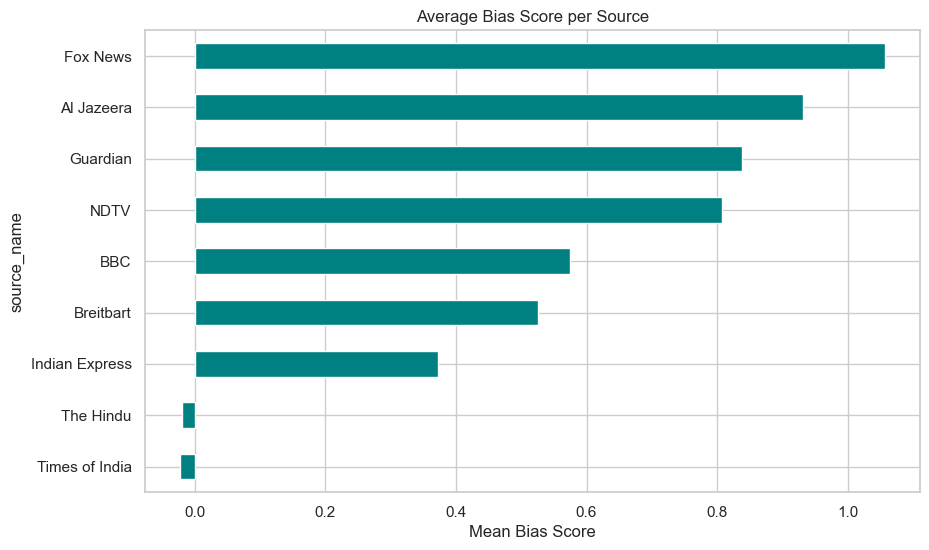

In [6]:
avg_bias = df_raw.groupby('source_name')['bias_score'].mean().sort_values()
avg_bias.plot(kind='barh', color='teal')
plt.title("Average Bias Score per Source")
plt.xlabel("Mean Bias Score")
plt.show()

## 6. Story Framing Examples (Clusters)
Using our **Semantic Clustering** logic to see how the 'same' story is told differently.

In [7]:
# This section requires the aggregator to be run
import sys
sys.path.append('..')
from src.analysis.story_aggregator import aggregate_stories

clusters = aggregate_stories()
for c in clusters[:2]:
    print(f"\nSTORY CLUSTER {c['cluster_id']}")
    for h in c['headlines']:
        print(f"- [{h['source']}] {h['headline']}")
        print(f"  Bias: {h['bias_label']} ({h['bias_score']})")

C:\Users\vgang\Downloads\Bias-Detector\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating embeddings for 687 headlines...


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 3957.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



STORY CLUSTER 1
- [BBC] Badenoch accuses PM of misleading MPs over Mandelson vetting
  Bias: biased_negative (4.62)
- [Guardian] Badenoch says revelations that Mandelson failed security vetting shows Starmer misled MPs– UK politics live
  Bias: biased_negative (2.92)

STORY CLUSTER 3
- [BBC] Former Arsenal goalkeeper Alex Manninger dies after car struck by train in Austria
  Bias: neutral (0.75)
- [BBC] Ex-keeper Manninger dies after car hit by train
  Bias: neutral (0.0)
- [Al Jazeera] Ex-Arsenal and Liverpool keeper Manninger killed in car crash with train
  Bias: biased_negative (3.91)
